1.29 MAE

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torchmetrics as tm
import os

In [2]:
root_path = "/home/stefan/ioai-prep/kits/rooms"
seed = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


# Data

In [4]:
train_df = pd.read_csv(f"{root_path}/train.csv")
test_df = pd.read_csv(f"{root_path}/test.csv")

train_df.head()

,sample_id,question,answer,image_id
0,TRAIN0000,how many chairs are there,6,image888
1,TRAIN0001,how many picture are on the wall,2,image942
2,TRAIN0002,how many chairs are there,10,image1404
3,TRAIN0003,how many monitors are there in the table,2,image528
4,TRAIN0004,how many containers are there,3,image872


In [5]:
train_df = train_df[train_df['question'].str.len() <= 77] #.sample(frac=0.75, random_state=seed)
train_df = train_df[train_df['question'].str.startswith('how many')]

len(train_df)

1303

In [6]:
class CountingVQADataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.df["question"] = self.df["question"].apply(
            lambda x: x[0].upper() + x[1:] + "?"
        )

        self.image_dir = f"{root_path}/images"
        self.processor = processor

        self.augment = transforms.Compose(
            [
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
                transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
                transforms.RandomHorizontalFlip(p=0.3),
            ]
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, f"{row['image_id']}.png")

        image = Image.open(image_path).convert("RGB")

        question = row["question"]
        answer = row["answer"] if "answer" in self.df.columns else 0.0

        if "answer" in self.df.columns:
            image = self.augment(image)

        inputs = self.processor(
            text=question,
            images=image,
            return_tensors="pt",
            padding="max_length",
            max_length=77,
            truncation=True,
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "answer": torch.tensor(answer, dtype=torch.float32),
        }

    def __len__(self):
        return len(self.df)

In [7]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=seed)

train_dataset = CountingVQADataset(train_df, processor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

val_dataset = CountingVQADataset(val_df, processor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, drop_last=True)

In [8]:
batch = next(iter(train_loader))
{k:batch[k].shape for k in batch.keys()}

{'pixel_values': torch.Size([32, 3, 224, 224]),
 'input_ids': torch.Size([32, 77]),
 'attention_mask': torch.Size([32, 77]),
 'answer': torch.Size([32])}

# Model

In [9]:
class MultimodalVQAModel(nn.Module):
    def __init__(self, clip_model, frozen=True):
        super().__init__()
        self.vision_encoder = clip_model.vision_model
        self.text_encoder = clip_model.text_model
        self.vision_proj = clip_model.visual_projection
        self.text_proj = clip_model.text_projection

        proj_dim = clip_model.config.projection_dim  # 512

        if frozen:
            for param in self.vision_encoder.parameters():
                param.requires_grad = False
            for param in self.text_encoder.parameters():
                param.requires_grad = False
            for param in self.vision_proj.parameters():
                param.requires_grad = False
            for param in self.text_proj.parameters():
                param.requires_grad = False

        # Use CLIP's projection space for both modalities
        self.regressor = nn.Sequential(
            nn.Linear(proj_dim * 2, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        # Image features through CLIP projection
        vision_outputs = self.vision_encoder(pixel_values=pixel_values)
        image_embeds = vision_outputs.pooler_output  # (B, 768)
        image_feat = self.vision_proj(image_embeds)  # (B, 512)

        # Text features through CLIP projection
        text_outputs = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        )
        text_embeds = text_outputs.pooler_output  # (B, 512)
        text_feat = self.text_proj(text_embeds)  # (B, 512)

        # Normalize (like CLIP does)
        image_feat = image_feat / image_feat.norm(dim=-1, keepdim=True)
        text_feat = text_feat / text_feat.norm(dim=-1, keepdim=True)

        # Fusion
        context_vector = torch.cat([image_feat, text_feat], dim=1)  # (B, 1024)

        count = self.regressor(context_vector)
        return count.squeeze()

In [56]:
model = MultimodalVQAModel(clip_model, frozen=True).to(device)

# sanity check
model(
    batch["pixel_values"].to(device),
    batch["input_ids"].to(device),
    batch["attention_mask"].to(device),
).shape

torch.Size([32])

In [57]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
"number of trainable parameters: {:,}".format(num_params)

'number of trainable parameters: 591,873'

# Training

In [58]:
losses = []
epochs = 10
lr = 3e-4

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.HuberLoss()
scaler = torch.amp.GradScaler(device)
mae = tm.MeanAbsoluteError().to(device)

In [59]:
for epoch in range(epochs):
    running_loss = 0

    model.train()
    for batch in tqdm(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        answers = batch["answer"].to(device)

        with torch.amp.autocast(device):
            predictions = model(pixel_values, input_ids, attention_mask).squeeze()
            loss = criterion(predictions, answers.float())

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        losses.append(loss.item())

    model.eval()
    mae.reset()
    for batch in tqdm(val_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        answers = batch["answer"].to(device)

        with torch.no_grad():
            predictions = model(pixel_values, input_ids, attention_mask).squeeze()
            mae(predictions, answers)

    avg_loss = running_loss / len(train_loader)
    metric = mae.compute()
    scheduler.step(metric)
    print(f"Epoch {epoch+1}/{epochs}: loss={avg_loss:.4f}, metric={metric:.2f}")

100%|██████████| 8/8 [00:04<00:00,  1.96it/s]


Epoch 1/10: loss=1.3482, metric=1.64


100%|██████████| 8/8 [00:04<00:00,  1.98it/s]


Epoch 2/10: loss=1.0765, metric=1.51


100%|██████████| 8/8 [00:04<00:00,  1.94it/s]


...

Epoch 8/10: loss=0.7483, metric=1.31


100%|██████████| 8/8 [00:03<00:00,  2.09it/s]


Epoch 9/10: loss=0.7092, metric=1.35


100%|██████████| 8/8 [00:04<00:00,  1.98it/s]

Epoch 10/10: loss=0.6749, metric=1.29


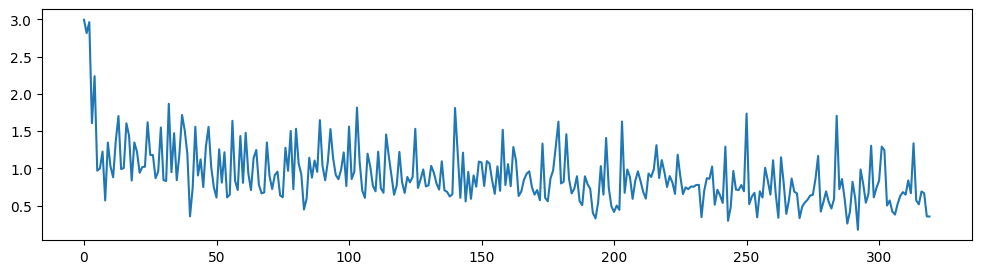

In [60]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

# Submission

In [66]:
model.eval()
test_dataset = CountingVQADataset(test_df, processor)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [67]:
predictions = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Generating predictions")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        pred = model(pixel_values, input_ids, attention_mask).squeeze().item()
        pred = max(0, int(round(pred)))
        predictions.append(pred)

Generating predictions: 100%|██████████| 367/367 [00:08<00:00, 44.78it/s]


In [68]:
submission_df = pd.DataFrame({"sample_id": test_df["sample_id"], "answer": predictions})
submission_df.head()

,sample_id,answer
0,TEST0000,5
1,TEST0001,2
2,TEST0002,3
3,TEST0003,4
4,TEST0004,4


array([[<Axes: title={'center': 'answer'}>]], dtype=object)

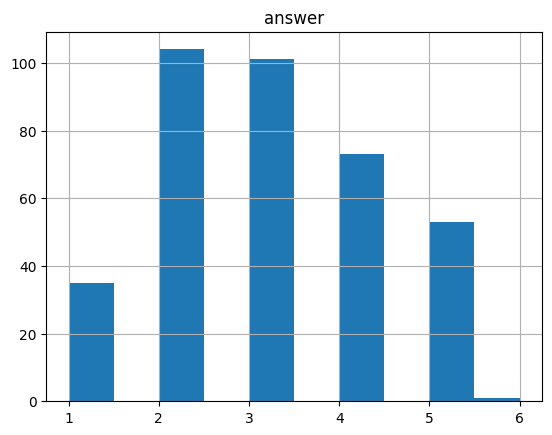

In [69]:
submission_df.hist()

In [70]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)